In [29]:
import glob

images = glob.glob("/kaggle/input/**/*.png", recursive=True)

# pick first 5 images
image_paths = images[:5]

print(image_paths)

['/kaggle/input/datasets/ketkirahegaonkar/graddatasets/classification_data/val/7/ede72bdbae3f743b8febe5433c49d126.png', '/kaggle/input/datasets/ketkirahegaonkar/graddatasets/classification_data/val/7/0853ab3a3dbadae1e6f28b933ddff809.png', '/kaggle/input/datasets/ketkirahegaonkar/graddatasets/classification_data/val/7/66fc91228ec5c614305dd54706f73f80.png', '/kaggle/input/datasets/ketkirahegaonkar/graddatasets/classification_data/val/7/86c1b099be1f08120cdc722e88738dc0.png', '/kaggle/input/datasets/ketkirahegaonkar/graddatasets/classification_data/val/7/73677ea9100c2fc6b88ba7442c90bcf9.png']


In [30]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image   # ✅ ADD THIS

In [31]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
print("Transform ok.")

Transform ok.


In [32]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models

# ✅ Device (FIX)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Load model
model = models.densenet121(pretrained=True)

# ✅ Set number of classes (IMPORTANT — match your dataset)
num_classes = 14   # change if different

model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# ✅ Move model to device
model = model.to(device)

# ✅ Evaluation mode (VERY IMPORTANT for Grad-CAM)
model.eval()

print("Model + Device ready ✅")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model + Device ready ✅


In [34]:
# Lists to store outputs
features = []
gradients = []

# Forward hook → saves feature maps
def forward_hook(module, input, output):
    features.append(output)

# Backward hook → saves gradients
def backward_hook(module, grad_in, grad_out):
    gradients.append(grad_out[0])

In [35]:
target_layer = model.features.denseblock4

# Register hooks
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

print("Hooks attached ✅")

Hooks attached ✅



Processing Image 1


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


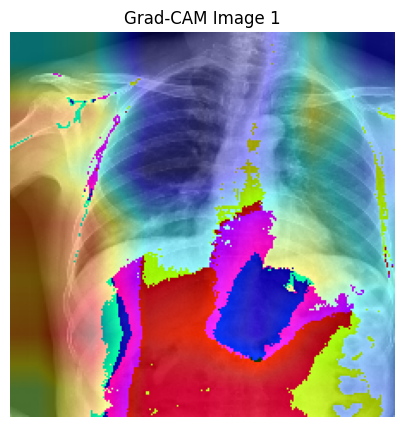


Processing Image 2


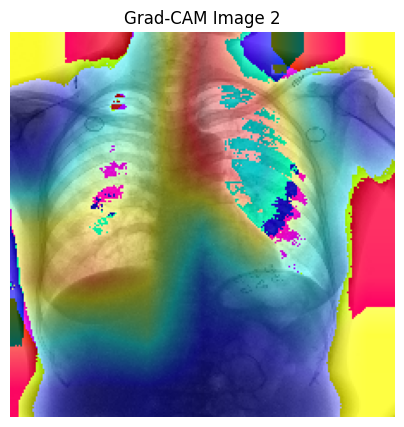


Processing Image 3


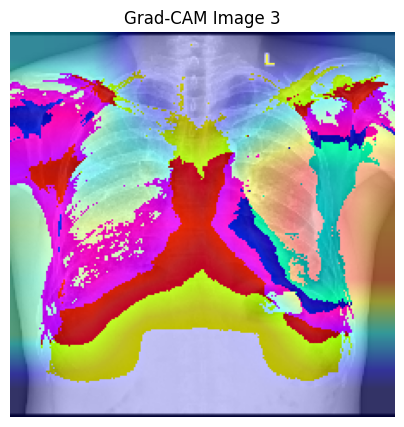


Processing Image 4


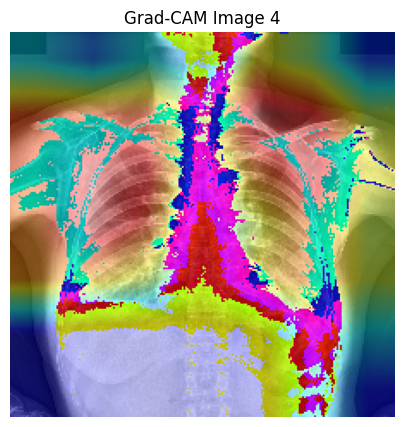


Processing Image 5


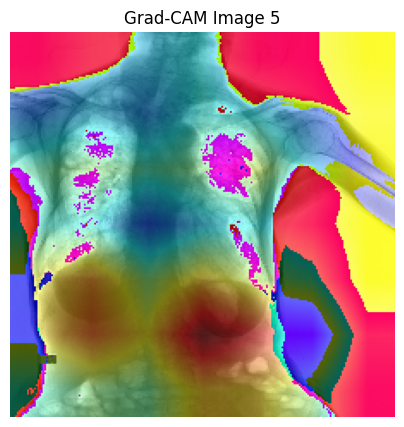

In [36]:
for idx, img_path in enumerate(image_paths):

    print(f"\nProcessing Image {idx+1}")

    # Load image
    image = Image.open(img_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    # Clear previous hooks data
    features.clear()
    gradients.clear()

    # Forward
    output = model(input_tensor)
    pred_class = output.argmax().item()

    # Backward
    model.zero_grad()
    output[0, pred_class].backward()

    # Grad-CAM
    grads = gradients[0].cpu().data.numpy()[0]
    fmap = features[0].cpu().data.numpy()[0]

    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(fmap.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * fmap[i]

    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam - cam.min()
    cam = cam / cam.max()

    # Overlay
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = heatmap * 0.4 + img

    # Show result
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM Image {idx+1}")
    plt.axis('off')
    plt.show()

In [37]:
!pip install albumentations

In [39]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt

In [41]:
transform = A.Compose([
    A.Resize(224, 224),
    
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=30, p=0.5),
    
    A.GaussianBlur(p=0.2),
    A.RandomGamma(p=0.3),
    
    A.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
    ToTensorV2()
])

In [42]:
img_path = image_paths[0]   # use any image
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print("Done.")

Done.


In [44]:
augmented = transform(image=image)
aug_image = augmented['image']

In [46]:
# CONVERSION (handles both tensor + numpy)

if hasattr(aug_image, 'permute'):  # if tensor
    aug_image = aug_image.permute(1, 2, 0).cpu().numpy()

# Normalize for display
aug_image = (aug_image - aug_image.min()) / (aug_image.max() - aug_image.min())

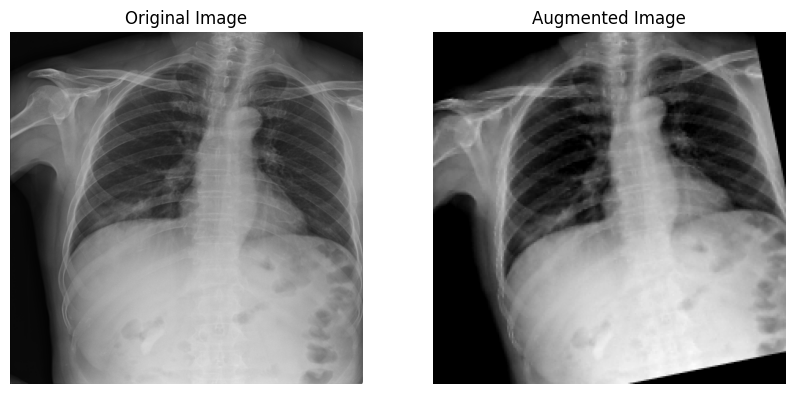

In [47]:
#  conversion
if hasattr(aug_image, 'permute'):
    aug_image = aug_image.permute(1, 2, 0).cpu().numpy()

# Normalize
aug_image = (aug_image - aug_image.min()) / (aug_image.max() - aug_image.min())

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Original
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis('off')

# Augmented
ax[1].imshow(aug_image)
ax[1].set_title("Augmented Image")
ax[1].axis('off')

plt.show()